<img src="https://devra.ai/analyst/notebook/6215/image.jpg" style="width: 100%; height: auto;" />

<div style="text-align:center; border-radius:15px; padding:15px; color:white; margin:0; font-family: 'Orbitron', sans-serif; background: #2E0249; background: #11001C; box-shadow: 0px 4px 8px rgba(0, 0, 0, 0.3); overflow:hidden; margin-bottom: 1em;">    <div style="font-size:150%; color:#FEE100"><b>Speed Dating and Attraction Outcomes Analysis</b></div>    <div>This notebook was created with the help of <a href="https://devra.ai/ref/kaggle" style="color:#6666FF">Devra AI</a></div></div>

## Table of Contents

- [Introduction](#Introduction)
- [Data Loading and Inspection](#Data-Loading-and-Inspection)
- [Data Cleaning and Preprocessing](#Data-Cleaning-and-Preprocessing)
- [Exploratory Data Analysis](#Exploratory-Data-Analysis)
- [Predictive Modeling](#Predictive-Modeling)
- [Summary and Future Work](#Summary-and-Future-Work)

# Introduction

Speed dating is not just a quirky social experiment but also a goldmine for data analysis. In this notebook, we dive deep into the speed dating and attraction outcomes dataset to uncover fascinating insights into human preferences and decisions. If you find these insights intriguing, feel free to upvote this notebook.

Our approach leverages detailed exploratory data analysis and predictive modeling techniques to understand what drives a match. Let's begin our journey.

In [1]:
# Importing libraries and setting up the environment
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib
matplotlib.use('Agg')  # Ensure Agg backend is used for matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

from pathlib import Path

# Helper function to resolve data file paths dynamically
DATA_ROOTS = [
    Path('/kaggle/input'),
    Path('/kaggle/input'),
    Path('/kaggle/input/datasets'),
]

def resolve_data_file(file_name=None, suffixes=None):
    suffixes = tuple(suffixes or [])
    for root in DATA_ROOTS:
        if not root.exists():
            continue
        matches = [p for p in root.rglob('*') if p.is_file()]
        if file_name:
            exact = [p for p in matches if p.name == file_name]
            if exact:
                return exact[0]
        if suffixes:
            typed = [p for p in matches if p.suffix.lower() in suffixes]
            if typed:
                return typed[0]
    raise FileNotFoundError(f'Could not resolve data file: {file_name or suffixes}')

print('Imports and helper functions loaded.')

Imports and helper functions loaded.


In [2]:
# Loading the datasets

# Resolving the file paths dynamically for the master dataset and the data dictionary
data_master_path = resolve_data_file(file_name='speed_dating_master.csv')
data_dict_path = resolve_data_file(file_name='data_dictionary.csv')

print(f"Master data file found at: {data_master_path}")
print(f"Data dictionary file found at: {data_dict_path}")

# Read the datasets into pandas DataFrames
df_master = pd.read_csv(data_master_path, encoding='ascii', delimiter=',')
df_dict = pd.read_csv(data_dict_path, encoding='utf-8', delimiter=',')

print('Datasets loaded successfully.')

Master data file found at: /kaggle/input/datasets/sergionefedov/speed-dating-and-attraction-outcomes/speed_dating_master.csv
Data dictionary file found at: /kaggle/input/datasets/sergionefedov/speed-dating-and-attraction-outcomes/data_dictionary.csv
Datasets loaded successfully.


# Data Loading and Inspection

Below, we inspect the first few rows and the basic information about the dataset. This helps in getting a sense of the structure and missing values, if any.

In [3]:
# Displaying the first few rows of the master dataset
df_master.head()

,event_id,male_id,female_id,male_age,female_age,age_gap,same_race,same_field,shared_interests,attr_of_female,...,male_pref_intel,female_pref_attr,female_pref_intel,male_self_attr,female_self_attr,male_goes_out,female_goes_out,male_decision,female_decision,match
0,0,P00000,P00006,28,29,1,0,0,5.3,2.6,...,18.3,14.9,23.6,8.4,5.0,often,very_often,0,0,0
1,0,P00000,P00007,28,26,2,0,0,9.0,8.0,...,18.3,35.6,16.5,8.4,6.2,often,rarely,1,1,1
2,0,P00000,P00008,28,32,4,0,0,2.6,5.0,...,18.3,35.6,17.8,8.4,4.9,often,very_often,0,1,0
3,0,P00000,P00009,28,22,6,0,1,2.8,3.3,...,18.3,14.9,22.3,8.4,6.4,often,often,0,1,0
4,0,P00000,P00010,28,27,1,0,0,3.4,5.3,...,18.3,30.9,16.1,8.4,4.4,often,rarely,0,1,0


In [4]:
# Getting a concise summary of the master dataset
df_master.info()

# Checking for missing values
missing_values = df_master.isnull().sum()
print(missing_values[missing_values > 0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14504 entries, 0 to 14503
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   event_id           14504 non-null  int64  
 1   male_id            14504 non-null  object 
 2   female_id          14504 non-null  object 
 3   male_age           14504 non-null  int64  
 4   female_age         14504 non-null  int64  
 5   age_gap            14504 non-null  int64  
 6   same_race          14504 non-null  int64  
 7   same_field         14504 non-null  int64  
 8   shared_interests   14504 non-null  float64
 9   attr_of_female     14504 non-null  float64
 10  sinc_of_female     14504 non-null  float64
 11  intel_of_female    14504 non-null  float64
 12  fun_of_female      14504 non-null  float64
 13  amb_of_female      14504 non-null  float64
 14  attr_of_male       14504 non-null  float64
 15  sinc_of_male       14504 non-null  float64
 16  intel_of_male      145

# Data Cleaning and Preprocessing

In this section, we check for missing values, ensure that data types are correctly set, and take a glance at some of the columns. Note that even though there are no dates in this dataset, in cases where dates are found, appropriate date type inference should be applied. Sometimes fixing data type issues can be as tricky as understanding human attraction; both require careful attention.

In [5]:
# Convert columns to the appropriate type if needed
# For instance, male_id and female_id might be better as strings if read as numbers
df_master['male_id'] = df_master['male_id'].astype(str)
df_master['female_id'] = df_master['female_id'].astype(str)

# Confirming conversion
print(df_master.dtypes[['male_id', 'female_id']])

# If missing values in numeric columns are encountered, we may consider imputation or dropping columns
print('Missing values per column:')
print(df_master.isnull().sum().sort_values(ascending=False).head(10))

male_id      object
female_id    object
dtype: object
Missing values per column:
event_id            0
male_id             0
female_id           0
male_age            0
female_age          0
age_gap             0
same_race           0
same_field          0
shared_interests    0
attr_of_female      0
dtype: int64


# Exploratory Data Analysis

We now explore the dataset visually. The analysis includes histograms for numeric features, a correlation heatmap (only if there are at least four numeric columns), and a pair plot for a select few attributes. The objective here is to identify patterns and relationships that highlight what influences the outcome of a match. Notice that a few visualization techniques may be repurposed to give us diverse views of the same data.

Total numeric columns: 26


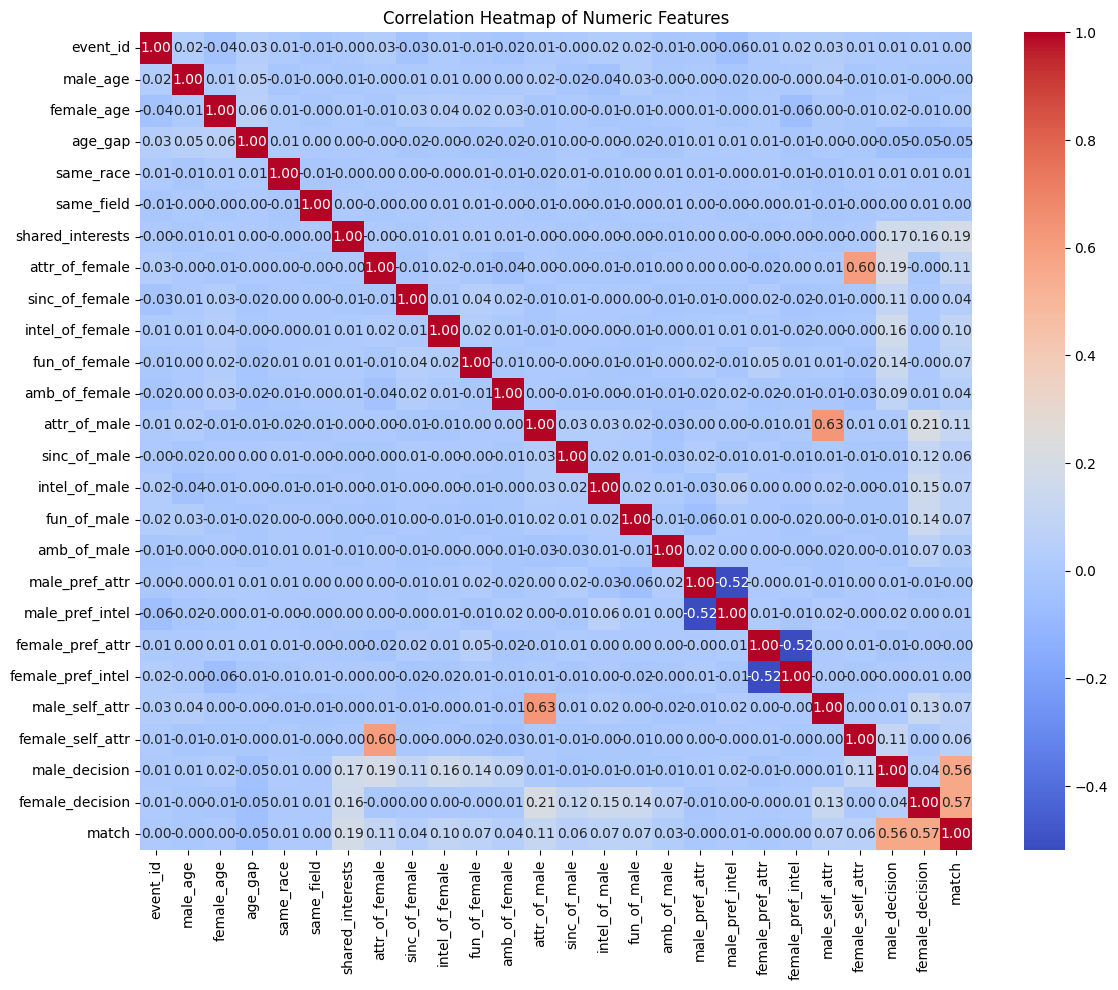

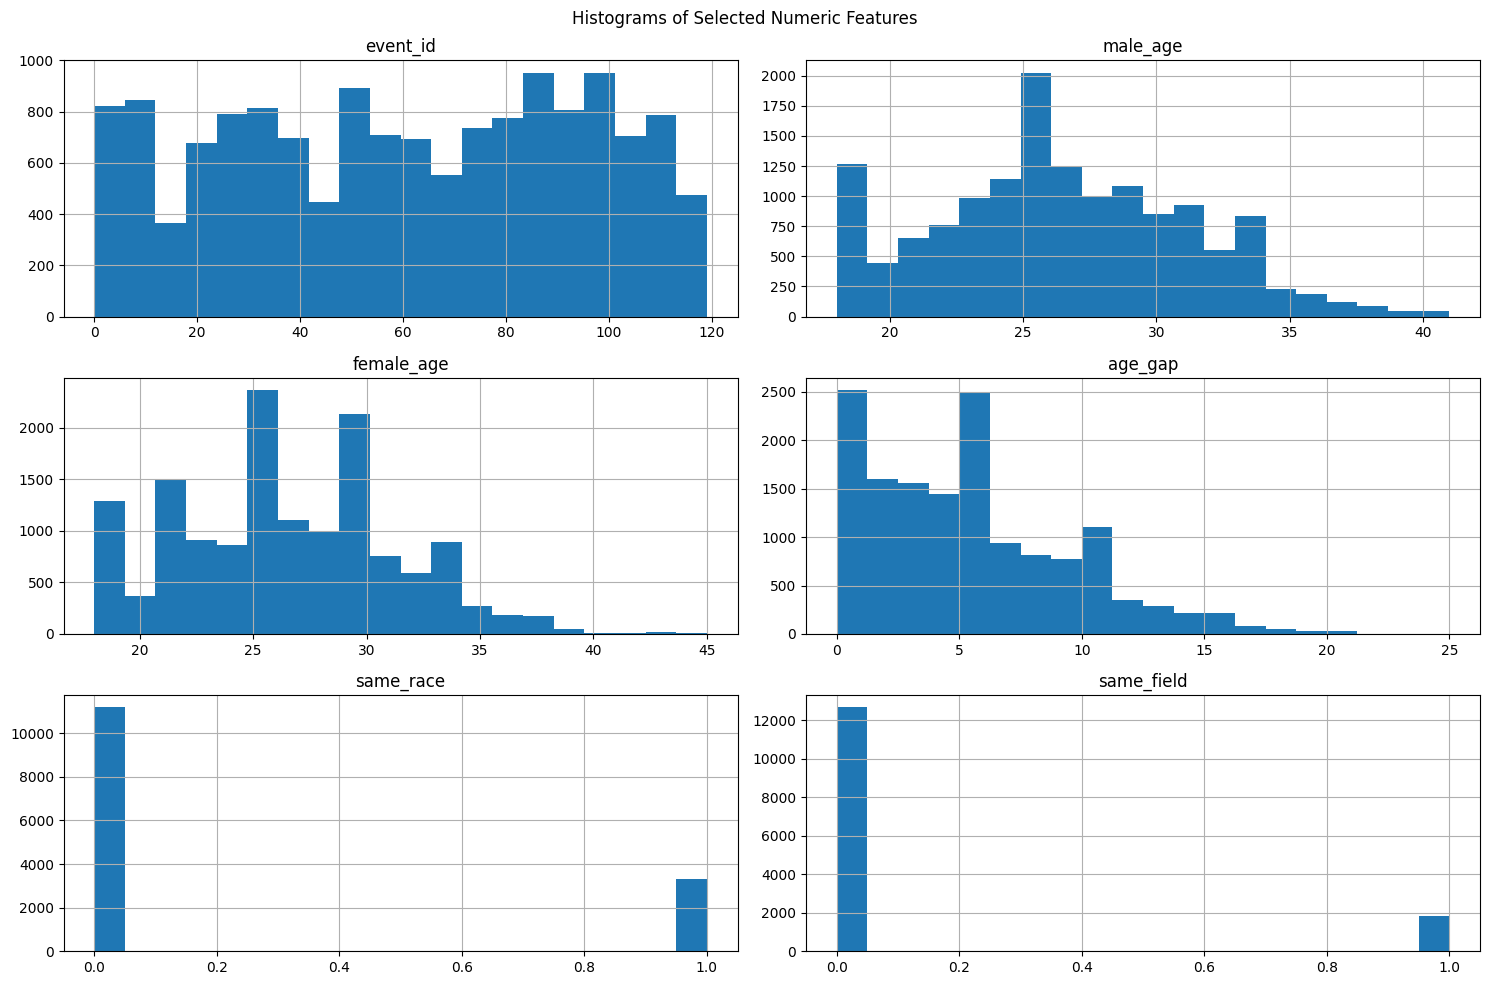

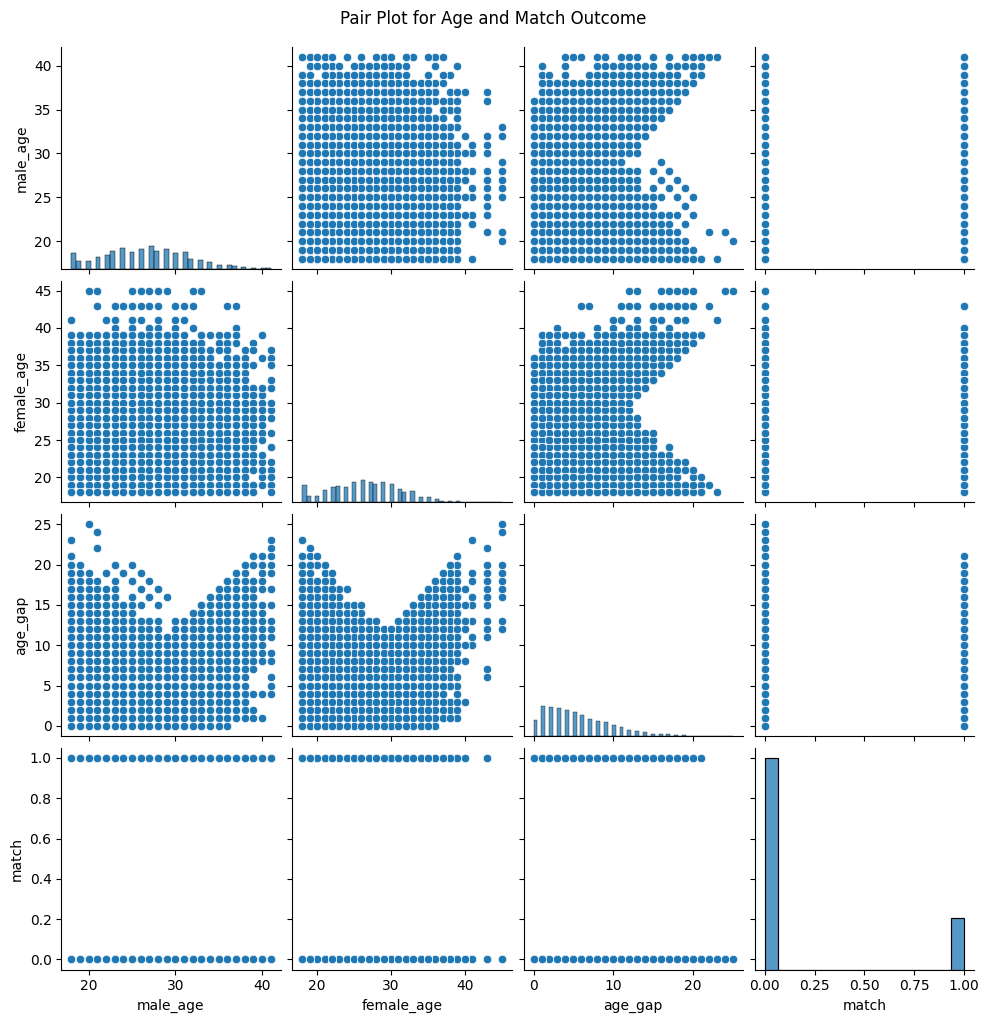

In [6]:
# Separate numeric features for correlation analysis
numeric_df = df_master.select_dtypes(include=[np.number])
print(f"Total numeric columns: {numeric_df.shape[1]}")

# If there are four or more numeric columns, display a heatmap
if numeric_df.shape[1] >= 4:
    plt.figure(figsize=(12, 10))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation Heatmap of Numeric Features')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for a correlation heatmap.')

# Histograms for a few numeric columns
num_cols = numeric_df.columns[:6]  # Take first 6 numeric columns for simplicity
numeric_df[num_cols].hist(bins=20, figsize=(15, 10))
plt.suptitle('Histograms of Selected Numeric Features')
plt.tight_layout()
plt.show()

# Pairplot for a select subset
subset_cols = ['male_age', 'female_age', 'age_gap', 'match']
if all(col in df_master.columns for col in subset_cols):
    sns.pairplot(df_master[subset_cols], diag_kind='hist')
    plt.suptitle('Pair Plot for Age and Match Outcome', y=1.02)
    plt.show()
else:
    print('Some required columns are missing for the pair plot.')

# Predictive Modeling

Now, the moment we have all been waiting for: building a predictor as reliable as a well-timed witty remark during a speed date. We attempt to predict whether a match occurs (binary classification) using selected features from the dataset. We evaluate the model using accuracy, a confusion matrix, and even measure the importance of features using permutation importance.

Accuracy of the Random Forest model: 0.8059


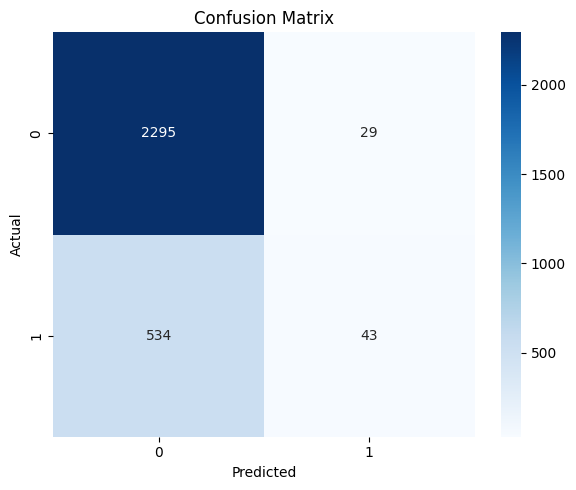

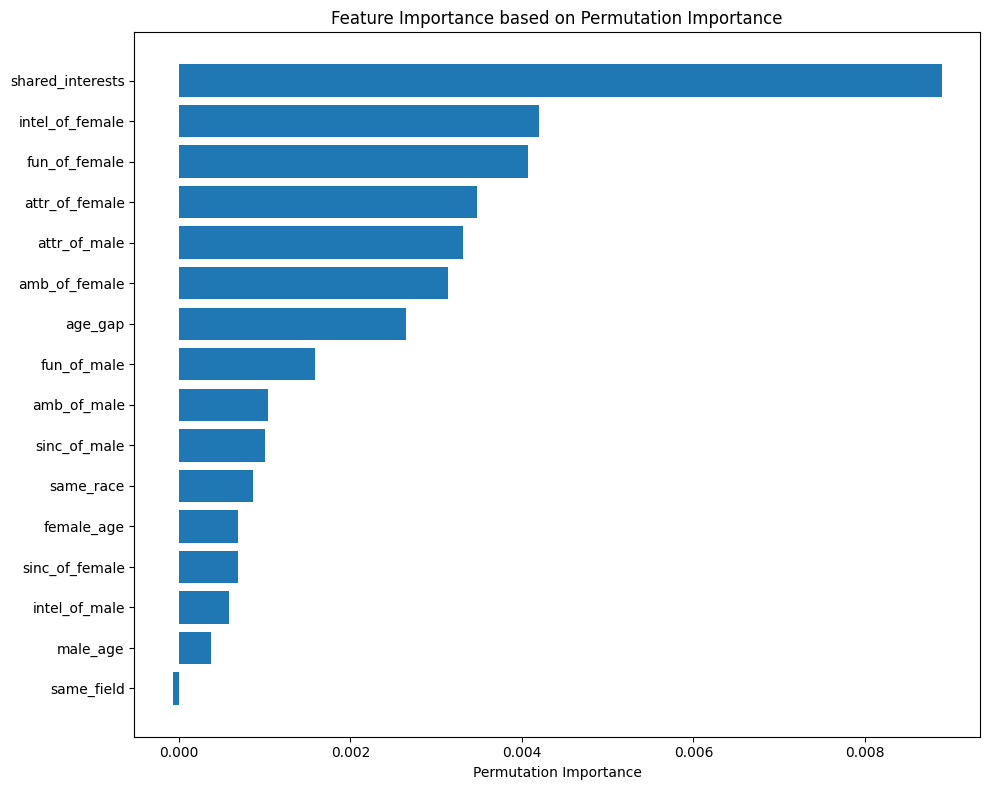

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.inspection import permutation_importance

# Select features for the prediction
# We purposefully choose features hypothesized to influence match outcomes
feature_cols = [
    'male_age', 'female_age', 'age_gap', 'same_race', 'same_field',
    'shared_interests', 'attr_of_female', 'sinc_of_female', 'intel_of_female',
    'fun_of_female', 'amb_of_female', 'attr_of_male', 'sinc_of_male',
    'intel_of_male', 'fun_of_male', 'amb_of_male'
]

# Define target variable
target_col = 'match'

# Drop rows with missing values in selected features and target
df_model = df_master[feature_cols + [target_col]].dropna()

X = df_model[feature_cols]
y = df_model[target_col]

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the random forest classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Generate predictions and compute accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the Random Forest model: {accuracy:.4f}")

# Displaying confusion matrix using heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Permutation importance
perm_importance = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=42)
sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(10, 8))
plt.barh(np.array(feature_cols)[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel('Permutation Importance')
plt.title('Feature Importance based on Permutation Importance')
plt.tight_layout()
plt.show()

# A note on feature selection: As in dating, not all features end up being influential at the end of the night.

# Summary and Future Work

This notebook explored the speed dating and attraction dataset with a mixture of descriptive analytics and predictive modeling. We used a variety of visualization techniques to understand data patterns and built a random forest predictor for match outcomes. The modeling results, including accuracy and feature importance, provide a basic baseline that invites further exploration.

Future work may involve:

- Incorporating additional features and engineering interaction effects
- Trying alternative predictive models such as boosting or logistic regression
- Analyzing temporal patterns if additional date information becomes available

If you found this exploration insightful or entertaining, please consider upvoting it.